In [200]:
from typing import TypedDict,List,Annotated,Literal,Optional
import operator
import os
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage,HumanMessage

In [201]:
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENROUTER_API_KEY")
os.environ["OPENAI_BASE_URL"] = "https://openrouter.ai/api/v1"

In [202]:
tool=TavilySearchResults(max_results=2)
results=tool.invoke({"query":"ChatGPT version releases and updates from 2022 to 2026"})
results

[{'title': 'ChatGPT — Release Notes',
  'url': 'https://help.openai.com/en/articles/6825453-chatgpt-release-notes',
  'content': 'Retiring GPT-4o and other legacy models\n   ChatGPT updates: Better file uploads, easier copying, and more reliable long chats\n   Web\n   Android\n   iOS\n   Web, iOS, and Android\n   February 12, 2026\n   ChatGPT Voice Update\n   February 10, 2026\n   Updates to deep research\n   GPT-5.2 Instant Update\n   February 9, 2026\n   Testing ads in ChatGPT (Free, Go)\n   February 4, 2026\n   Update on thinking time settings for GPT-5.2 Thinking in ChatGPT\n   February 2, 2026\n   Introducing the Codex app\n   January 30, 2026\n   More visual responses\n   January 29, 2026\n   Retiring GPT-4o and other legacy models\n   January 26, 2026\n   Improvements to search response quality in Voice\n   January 22, 2026\n   5.2 Personality System Prompt Update\n   January 20, 2026\n   Voice Updates\n   Rolling out age prediction [...] Sunsetting the “Nerdy” base style\n   Ma

In [203]:
class Task(BaseModel):
    id:int
    title:str
    goal:str=Field(...,description="One sentence describing what the reader should be able to do/understand after this section")
    bullets:List[str]=Field(
        ...,min_length=3,max_length=7,description="3-5  only max 5 concrete,non overlapping subpoints to cover in this section"
    )
    target_words: int = Field(
        ...,description="Target word count for this section (120-450)"
    )
    section_type:Literal["intro", "core", "examples","checkList","common_mistakes","conclusion"]=Field(
        ...,description="Use 'common_mistakes' exactly once in the plan"
    )
    # brief:str = Field(...,desription="What to cover")
    tags:List[str]=Field(default_factory=list)
    requires_research:bool=False
    requires_citation:bool=False
    requires_code:bool=False

In [204]:
class Plan(BaseModel):
    blog_title:str
    audience:str=Field(...,description="Who the blog is for")
    tone:str=Field(...,description="Writing tone (e.g., practical,crisp)")
    blog_kind:Literal["explainer","tutorial","news_roundup","comparison","system_design"]="explainer"
    constraints:List[str]=Field(default_factory=list)
    tasks:List[Task]

In [205]:
class EvidenceItem(BaseModel):
    title:str
    url:str
    published_at:Optional[str]=None
    snippet:Optional[str]=None
    source:Optional[str]=None

In [206]:
class RouterDecision(BaseModel):
    needs_research:bool
    mode:Literal["closed_book","hybrid","open_book"]
    queries:List[str]=Field(default_factory=list)

In [207]:
class EvidencePack(BaseModel):
    evidence:List[EvidenceItem]=Field(default_factory=list)

In [208]:
class State(TypedDict):
    topic:str
    mode:str
    needs_research:bool
    queries:List[str]
    evidence:List[EvidenceItem]
    plan:Optional[Plan]
    #reducer : results from workers get concatanated automatically
    sections:Annotated[List[tuple[int,str]],operator.add]#will have output of each worker node
    final:str

    # reucer/image
    merged_md:str
    md_with_placeholder:str
    image_specs:List[dict]

    

In [209]:
class ImageSpec(BaseModel):
    placeholder:str=Field(...,description="e.g. [[IMAGE_1]]")
    filename:str=Field(...,description="Save under images/, e.g. qkv_flow.png")
    alt:str
    caption:str
    prompt:str=Field(...,description="Prompt to send to the image model")
    size: Literal["1024x1024","1024x1536","1536x1024"]="1024x1024"
    quality:Literal["low","medium","high"]="medium"

class GlobalImage(BaseModel):
    md_with_placeholder:str
    images:List[ImageSpec]=Field(default_factory=list)

In [210]:
llm = ChatOpenAI(
    model=os.getenv("LLM_MODEL", "nvidia/nemotron-3-super-120b-a12b:free"),
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [211]:
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false): evergreen concepts.
- hybrid (needs_research=true): evergreen + needs up-to-date examples/tools/models.
- open_book (needs_research=true): volatile weekly/news/"latest"/pricing/policy.

If needs_research=true:
- Output 3–10 high-signal, scoped queries.
- For open_book weekly roundup, include queries reflecting last 7 days.
"""
def router_node(state:State)->dict:
    topic=state["topic"]
    decider=llm.with_structured_output(RouterDecision, method="function_calling")
    decision=decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic:{topic}"),
        ]
    )
    return {
        "needs_research":decision.needs_research,
        "mode":decision.mode,
        "queries":decision.queries
    }
# for condition
def route_next(state:State)->str:
    return "research" if state["needs_research"] else "orchestrator"

In [212]:
# research node
def _tavily_search(query:str,max_results:int=5) ->List[dict]:
    tool=TavilySearchResults(max_results=max_results)
    results=tool.invoke({"query":query})

    normalized:List[dict]=[]
    for r in results or []:
        normalized.append(
            {"title":r.get("title") or "",
            "url":r.get("url") or "",
            "snippet":r.get("content") or r.get("snippet") or "",
            "published_at":r.get("published_date") or r.get("published_at") ,
            "source":r.get("source") or "",
             }
        )
        return normalized

In [213]:
RESEARCH_SYSTEM = """You are a research synthesizer.

Given raw web search results, produce EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources.
- Normalize published_at to ISO YYYY-MM-DD if reliably inferable; else null (do NOT guess).
- Keep snippets short.
- Deduplicate by URL.
"""

def research_node(state:State) -> dict:

    # taking the first 10 queries form state
    queries=(state.get("queries",[]) or [])
    max_results=6

    raw_results:List[dict]=[]
    for q in queries:
        raw_results.extend(_tavily_search(q,max_results=max_results))

    if not raw_results:
        return {"evidence":[]}

    extractor =llm.with_structured_output(EvidencePack, method="json_mode")
    pack=extractor.invoke(
        [SystemMessage(content=RESEARCH_SYSTEM),
         HumanMessage(content=f"Raw results:\n{raw_results}")]
    )

    dedup={}
    for e in pack.evidence:
        if e.url:
            dedup[e.url]=e
    return {"evidence":list(dedup.values())}

In [214]:
def orchestrator(state:State)->dict:
     evidence=state.get("evidence",[])
     mode=state.get("mode","closed_book")
     plan=llm.with_structured_output(Plan, method="function_calling").invoke(
          [
               SystemMessage(
                    content=(
                        """You are a senior technical writer and developer advocate.
                         Produce a highly actionable outline for a technical blog post.

                         Requirements:
                         - 5–9 tasks, each with goal + 3–6 bullets + target_words.
                         - Tags are flexible; do not force a fixed taxonomy.

                         Grounding:
                         - closed_book: evergreen, no evidence dependence.
                         - hybrid: use evidence for up-to-date examples; mark those tasks requires_research=True and requires_citations=True.
                         - open_book: weekly/news roundup:
                         - Set blog_kind="news_roundup"
                         - No tutorial content unless requested
                         - If evidence is weak, plan should explicitly reflect that (don’t invent events).

                         Output must match Plan schema.
                         """
                    )
               ),
               HumanMessage(content=f"Topic:{state['topic']}\n\n"
                                   f"Mode:{mode}\n\n"
                                   f"Evidence (Only use for fresh claims; may be empty):\n"
                                   f"{[e.model_dump() for e in evidence][:16]}"
               



                            ),
          ]
          
     )
     return {"plan":plan}

In [215]:
#deciding how many worker will be there
# this function checks how many tasks/sections are there in the plan object and creates as many workers
# triggers for every state a worker(using send api)
def fanout(state:State):
    return [Send("worker",
                 {
                     "task":task,
                     "topic":state['topic'],
                     "mode":state["mode"],
                     "plan":state["plan"],
                     "evidence":[e.model_dump() for e in state.get("evidence",[])]})
            for task in state["plan"].tasks]


In [216]:
# task a worker is supposed to do,every worker performs work related to its own section
def worker(payload:dict)->dict:

    task=payload["task"]
    topic=payload["topic"]
    plan=payload["plan"]
    evidence=[EvidenceItem(**e) for e in payload.get("evidence",[])]
    mode=payload.get("mode","closed_book")
    blog_title=plan.blog_title

    bullets_text="\n-" + "\n-".join(task.bullets)

    evidence_text=""
    if evidence:
        evidence_text="\n".join(
            f"-{e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )

    section_md=llm.invoke(
        [
            SystemMessage(content="""You are a senior technical writer and developer advocate.
                                        Write ONE section of a technical blog post in Markdown.

                                        Constraints:
                                        - Cover ALL bullets in order.
                                        - Target words ±15%.
                                        - Output only section markdown starting with "## <Section Title>".

                                        Scope guard:
                                        - If blog_kind=="news_roundup", do NOT drift into tutorials (scraping/RSS/how to fetch).
                                        Focus on events + implications.

                                        Grounding:
                                        - If mode=="open_book": do not introduce any specific event/company/model/funding/policy claim unless supported by provided Evidence URLs.
                                        For each supported claim, attach a Markdown link ([Source](URL)).
                                        If unsupported, write "Not found in provided sources."
                                        - If requires_citations==true (hybrid tasks): cite Evidence URLs for external claims.

                                        Code:
                                        - If requires_code==true, include at least one minimal snippet.
                                        """),
            HumanMessage(
                content=(
                    f"Blog title:{blog_title}\n"
                    f"Audience:{plan.audience}\n"
                    f"Tone:{plan.tone}\n"
                    f"Blog Kind:{plan.blog_kind}\n"
                    f"Constraints:{plan.constraints}\n"
                    f"Topic:{topic}\n"
                    f"Mode:{mode}\n"
                    f"Section title:{task.title}\n"
                    f"Section type:{task.section_type}\n"
                    f"Goal:{task.goal}\n"
                    f"Target words:{task.target_words}\n"
                    f"Tags:{task.tags}\n"
                    f"requires_research:{task.requires_research}\n"
                    f"requires_citation:{task.requires_citation}\n"
                    f"requires_code:{task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (Only use these urls when citing):\n{evidence_text}"
                    "Return only the section content in Markdown."
            )),
        ]
    ).content.strip()

    return {"sections":[(task.id,section_md)]}

In [217]:
import re

def _safe_slug(title: str) -> str:
    s = title.strip().lower()
    s = re.sub(r"[^a-z0-9 _-]+", "", s)  # strips colons, apostrophes, etc.
    s = re.sub(r"\s+", "_", s).strip("_")
    return s or "blog"

In [218]:
# from pathlib import Path

# def reducer(state:State) -> dict:

#     title = state["plan"].blog_title
#     body="\n\n".join(state["sections"]).strip()
#     # state section is a list of strings one section above it a line change below it also line change another section

#     final_md=f"#{title}\n\n{body}\n"

#     # save to file
#     filename = _safe_slug(title)+".md"
#     output_path=Path(filename)
#     output_path.write_text(final_md,encoding="utf-8")

#     return {"final": final_md}

In [219]:
# changing reducer to subgraph
# mergecontent ->decide images-> generate_and place images
from pathlib import Path
def merge_content(state:State)->dict:
    plan=state["plan"]

    ordered_sections = [md for _ , md in sorted(state["sections"],key=lambda x:x[0])]
    body="\n\n".join(ordered_sections).strip()
    merged_md=f"# {plan.blog_title}\n\n{body}\n"
    return {"merged_md":merged_md}

DECIDE_IMAGES_SYSTEM = """You are an expert technical editor.
Decide if images/diagrams are needed for THIS blog.

Rules:
- Max 3 images total.
- Each image must materially improve understanding (diagram/flow/table-like visual).
- Insert placeholders exactly: [[IMAGE_1]], [[IMAGE_2]], [[IMAGE_3]].
- If no images needed: md_with_placeholders must equal input and images=[].
- Avoid decorative images; prefer technical diagrams with short labels.
Return strictly GlobalImagePlan.

"""

def decide_images(state:State)->dict:

    planner=llm.with_structured_output(GlobalImage)
    merged_md=state["merged_md"]
    plan=state["plan"]
    assert plan is not None
    image_plan = planner.invoke(
        [
            SystemMessage(content=DECIDE_IMAGES_SYSTEM),
            HumanMessage(content=
                         f"Blog kind :{plan.blog_kind}\n"
                         f"Topic: {state['topic']}/\n\n"
                         "Insert Placeholder + propose image prompts.\n\n"
                         f"{merged_md}"),
        ]
    )
    return {"md_with_placeholder":image_plan.md_with_placeholder,"image_specs":[img.model_dump() for img in image_plan.images],}

def _gemini_generate_image_bytes(prompt: str) -> bytes:
    """
    Returns raw image bytes generated by Gemini.
    Requires: pip install google-genai
    Env var: GOOGLE_API_KEY
    """
    from google import genai
    from google.genai import types

    api_key = os.environ.get("GOOGLE_API_KEY")
    if not api_key:
        raise RuntimeError("GOOGLE_API_KEY is not set.")

    client = genai.Client(api_key=api_key)

    resp = client.models.generate_content(
        model="gemini-2.5-flash-image",
        contents=prompt,
        config=types.GenerateContentConfig(
            response_modalities=["IMAGE"],
            safety_settings=[
                types.SafetySetting(
                    category="HARM_CATEGORY_DANGEROUS_CONTENT",
                    threshold="BLOCK_ONLY_HIGH",
                )
            ],
        ),
    )

    # Depending on SDK version, parts may hang off resp.candidates[0].content.parts
    parts = getattr(resp, "parts", None)
    if not parts and getattr(resp, "candidates", None):
        try:
            parts = resp.candidates[0].content.parts
        except Exception:
            parts = None

    if not parts:
        raise RuntimeError("No image content returned (safety/quota/SDK change).")

    for part in parts:
        inline = getattr(part, "inline_data", None)
        if inline and getattr(inline, "data", None):
            return inline.data

    raise RuntimeError("No inline image bytes found in response.")


def _safe_slug(title: str) -> str:
    s = title.strip().lower()
    s = re.sub(r"[^a-z0-9 _-]+", "", s)
    s = re.sub(r"\s+", "_", s).strip("_")
    return s or "blog"


def generate_and_place_images(state: State) -> dict:
    plan = state["plan"]
    assert plan is not None

    md = state.get("md_with_placeholders") or state["merged_md"]
    image_specs = state.get("image_specs", []) or []

    # If no images requested, just write merged markdown
    if not image_specs:
        filename = f"{_safe_slug(plan.blog_title)}.md"
        Path(filename).write_text(md, encoding="utf-8")
        return {"final": md}

    images_dir = Path("images")
    images_dir.mkdir(exist_ok=True)

    for spec in image_specs:
        placeholder = spec["placeholder"]
        filename = spec["filename"]
        out_path = images_dir / filename

        # generate only if needed
        if not out_path.exists():
            try:
                img_bytes = _gemini_generate_image_bytes(spec["prompt"])
                out_path.write_bytes(img_bytes)
            except Exception as e:
                # graceful fallback: keep doc usable
                prompt_block = (
                    f"> **[IMAGE GENERATION FAILED]** {spec.get('caption','')}\n>\n"
                    f"> **Alt:** {spec.get('alt','')}\n>\n"
                    f"> **Prompt:** {spec.get('prompt','')}\n>\n"
                    f"> **Error:** {e}\n"
                )
                md = md.replace(placeholder, prompt_block)
                continue

        img_md = f"![{spec['alt']}](images/{filename})\n*{spec['caption']}*"
        md = md.replace(placeholder, img_md)

    filename = f"{_safe_slug(plan.blog_title)}.md"
    Path(filename).write_text(md, encoding="utf-8")
    return {"final": md}

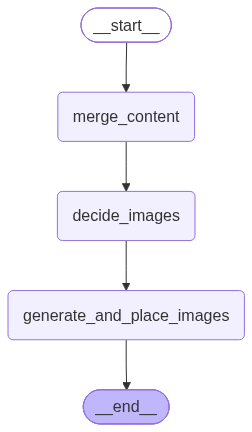

In [220]:
reducer_graph=StateGraph(State)
reducer_graph.add_node("merge_content",merge_content)
reducer_graph.add_node("decide_images",decide_images)
reducer_graph.add_node("generate_and_place_images",generate_and_place_images)
reducer_graph.add_edge(START,"merge_content")
reducer_graph.add_edge("merge_content","decide_images")
reducer_graph.add_edge("decide_images","generate_and_place_images")
reducer_graph.add_edge("generate_and_place_images",END)
reducer_subgraph=reducer_graph.compile()

reducer_subgraph

In [221]:
g=StateGraph(State)
g.add_node("router",router_node)
g.add_node("research",research_node)
g.add_node("orchestrator",orchestrator)
g.add_node("worker", worker)
g.add_node("reducer",reducer_subgraph)

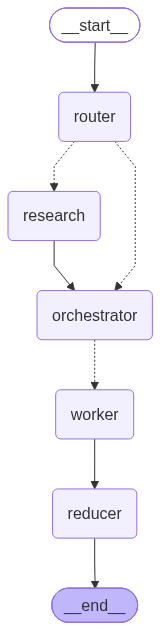

In [222]:
g.add_edge(START,"router")
g.add_conditional_edges("router",route_next,{"research":"research","orchestrator":"orchestrator"})
g.add_edge("research","orchestrator")
g.add_conditional_edges("orchestrator",fanout,["worker"])
g.add_edge("worker","reducer")
g.add_edge("reducer",END)

app=g.compile()

app

In [223]:
def run(topic:str):
    out=app.invoke(
        {
            "topic":topic,
            "mode":"",
            "needs_research":False,
            "queries":[],
            "evidence":[],
            "plan":None,
            "sections":[],
            "final":""
        }
    )
    return out

In [224]:
run("State of multi modal llms  in 2026")

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '50', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset': '1786320000000'}, 'limit_source': 'openrouter_free_tier_daily', 'remedy_hint': 'Wait for the daily reset (see X-RateLimit-Reset), or purchase credits to raise your free-model daily limit.', 'provider_name': None}}, 'user_id': 'user_3G1gvZUQvunlwDCWGm5EooUeWWA'}

blog_title='Understanding Self-Attention: From Theory to Practice' audience='Software engineers and ML practitioners with basic linear algebra knowledge' tone='practical, crisp' tasks=[Task(id=1, title='Introduction to Attention Mechanisms', goal='Explain why attention was introduced and how self-attention differs from earlier mechanisms.', bullets=['Motivate attention as a solution to long-range dependency problems in RNNs and CNNs.', 'Introduce the query, key, value (QKV) analogy and its role in focusing computation.', 'Contrast self-attention with additive (Bahdanau) and dot‑product (Luong) attention used in seq‑to‑seq models.', 'Highlight how self-attention enables each token to attend to all tokens in the same sequence.'], target_words=150, section_type='intro', brief='Cover motivation, query-key-value intuition, and difference from recurrent/cnn.'), Task(id=2, title='Core Mechanics of Scaled Dot-Product Self-Attention', goal='Describe step‑by‑step how self-attention computes outp